In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv(r"E:\datasets_data_analyst\financial_fraud_dataset\PS_20174392719_1491204439457_log.csv")

In [5]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
# ---------------- CLEANING ----------------
df = df.drop_duplicates()

In [7]:
# Handle missing values
df['amount'] = df['amount'].fillna(df['amount'].median())


In [8]:
print("Dataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB
None

Summary Statistics:
               step        amount  oldbalanceOrg  newbalanceOrig  \
count  6.362620e+06  6.362620e+06   6.362620e+06    6.362620e+06   
mean   2.433972e+02  1.798619e+05   8.338831e+05    8.551137e+05   
std    1.423320e+02  6.038582e+05   2.888243e+06    2.924049e+06   
min    1.000000e+00  0.000000e+00   0.000000e+00    0.000000e+00   
25%    1.560000e+02  1.338957e+04   0.000000e+00    0.000000e+00  

In [9]:
print("Dataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB
None

Summary Statistics:
               step        amount  oldbalanceOrg  newbalanceOrig  \
count  6.362620e+06  6.362620e+06   6.362620e+06    6.362620e+06   
mean   2.433972e+02  1.798619e+05   8.338831e+05    8.551137e+05   
std    1.423320e+02  6.038582e+05   2.888243e+06    2.924049e+06   
min    1.000000e+00  0.000000e+00   0.000000e+00    0.000000e+00   
25%    1.560000e+02  1.338957e+04   0.000000e+00    0.000000e+00  

In [10]:
# ---------------- FRAUD ANALYSIS ----------------

fraud_rate = df['isFraud'].mean() * 100
print("\nFraud Rate (%):", fraud_rate)

# Fraud distribution
fraud_counts = df['isFraud'].value_counts()
print("\nFraud Count:")
print(fraud_counts)


Fraud Rate (%): 0.12908204481801522

Fraud Count:
isFraud
0    6354407
1       8213
Name: count, dtype: int64


In [11]:
# ---------------- TRANSACTION TYPE ANALYSIS ----------------

type_analysis = df.groupby('type').agg({
    'amount': ['sum', 'mean'],
    'isFraud': 'sum'
})
print("\nTransaction Type Analysis:")
print(type_analysis)


Transaction Type Analysis:
                amount                isFraud
                   sum           mean     sum
type                                         
CASH_IN   2.363674e+11  168920.242004       0
CASH_OUT  3.944130e+11  176273.964346    4116
DEBIT     2.271992e+08    5483.665314       0
PAYMENT   2.809337e+10   13057.604660       0
TRANSFER  4.852920e+11  910647.009645    4097


In [12]:
high_value = df[df['amount'] > df['amount'].quantile(0.95)]
print("\nHigh Value Transactions Count:", len(high_value))


High Value Transactions Count: 318131



Correlation Matrix:
                  amount  oldbalanceOrg  newbalanceOrig   isFraud
amount          1.000000      -0.002762       -0.007861  0.076688
oldbalanceOrg  -0.002762       1.000000        0.998803  0.010154
newbalanceOrig -0.007861       0.998803        1.000000 -0.008148
isFraud         0.076688       0.010154       -0.008148  1.000000


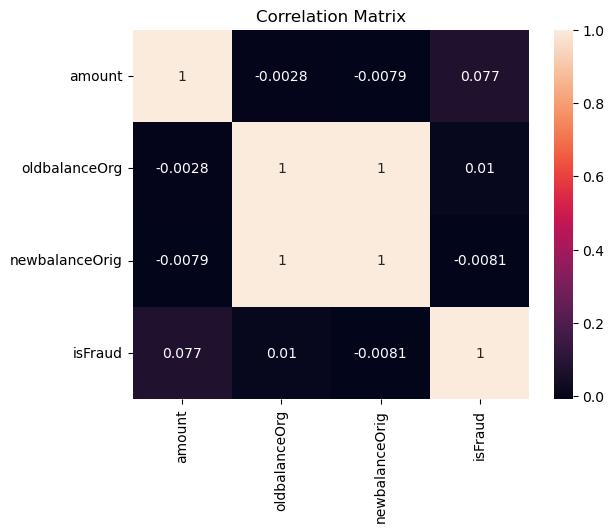

In [13]:
#CORRELATION
corr = df[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'isFraud']].corr()
print("\nCorrelation Matrix:")
print(corr)

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()


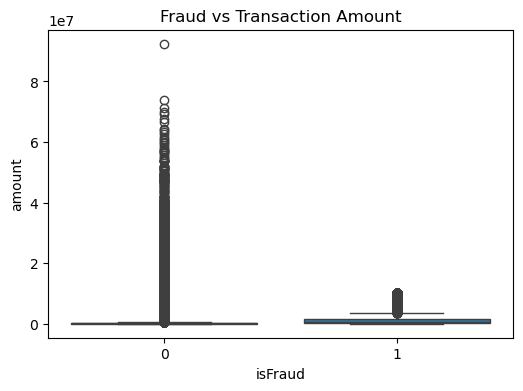

In [14]:
#Visualisation
# Fraud vs Amount
plt.figure(figsize=(6,4))
sns.boxplot(x='isFraud', y='amount', data=df)
plt.title("Fraud vs Transaction Amount")
plt.show()


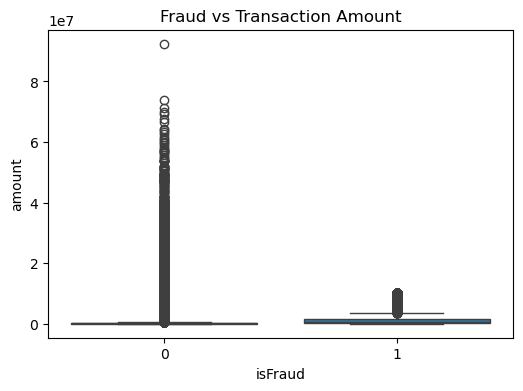

In [15]:
# Fraud vs Amount
plt.figure(figsize=(6,4))
sns.boxplot(x='isFraud', y='amount', data=df)
plt.title("Fraud vs Transaction Amount")
plt.show()


In [20]:
print(df['amount'].nunique())

5316900


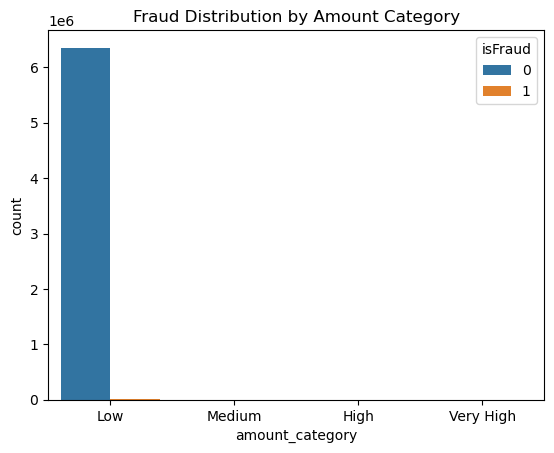

In [22]:
df['amount_category'] = pd.cut(
    df['amount'],
    bins=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)
sns.countplot(x='amount_category', hue='isFraud', data=df)
plt.title("Fraud Distribution by Amount Category")
plt.show()

In [29]:
df['balance_diff'] = df['oldbalanceOrg'] - df['newbalanceOrig']

In [31]:
print(df.columns)

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'amount_category', 'balance_diff'],
      dtype='object')


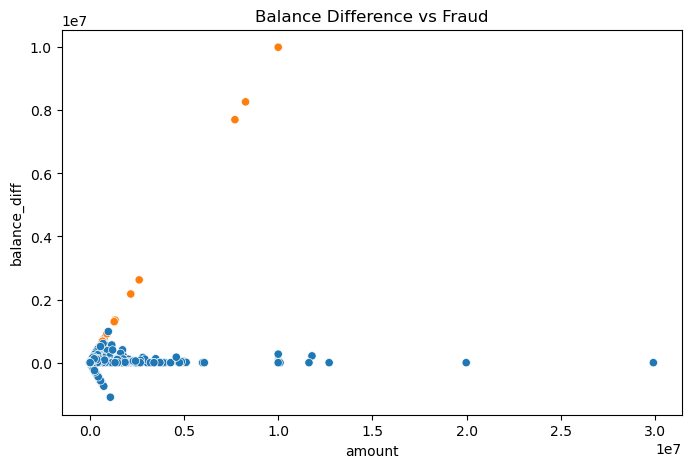

In [44]:
sample_df = df.sample(10000)

plt.figure(figsize=(8,5))
sns.scatterplot(
    x='amount', 
    y='balance_diff', 
    hue='isFraud', 
    data=sample_df,
    legend=False
)

plt.title("Balance Difference vs Fraud")
plt.show()

In [47]:
fraud_by_type = df.groupby('type')['isFraud'].mean() * 100
print("\nFraud Rate by Transaction Type (%):")
print(fraud_by_type)

suspicious_cases = df['isFlaggedFraud'].sum()
print("\nSuspicious Transactions Detected:", suspicious_cases)


Fraud Rate by Transaction Type (%):
type
CASH_IN     0.000000
CASH_OUT    0.183955
DEBIT       0.000000
PAYMENT     0.000000
TRANSFER    0.768799
Name: isFraud, dtype: float64

Suspicious Transactions Detected: 16
